<a href="https://colab.research.google.com/github/aman8122/data-science-Assignments/blob/main/week2_Aman_sain__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
from google.colab import files # This lia

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (3).csv


**Import** **libraries**

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

**load dataset**

In [194]:
ev_df=pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [195]:
ev_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [196]:
ev_df.shape

(2640, 12)

In [197]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


**Data preprocessing** **and** **Exploratory data analysis**


Check missing value

In [198]:
ev_df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


check duplicate value

In [199]:
print(ev_df.duplicated().sum())

0


In [200]:
num_cols = ev_df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')

starts summery and outlier detection

In [201]:
ev_df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


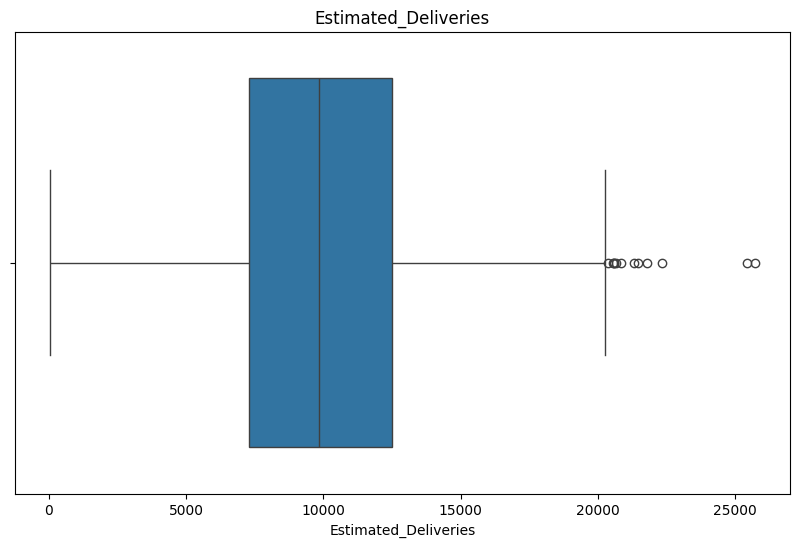

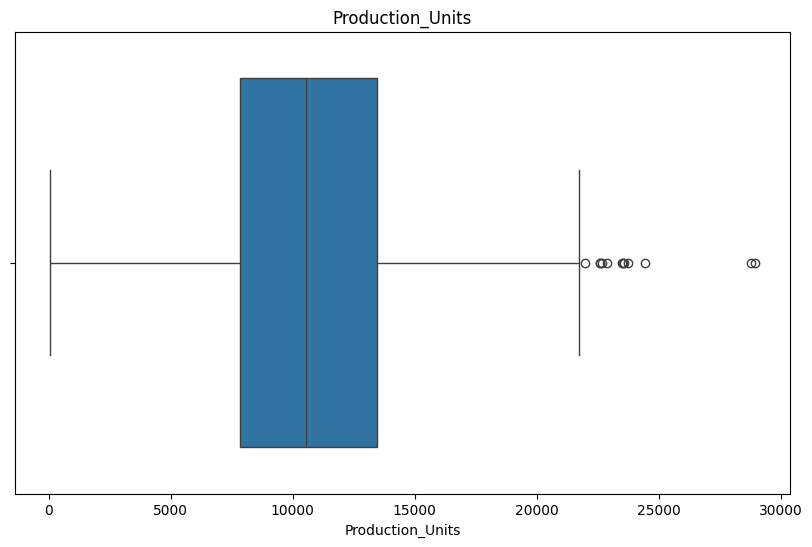

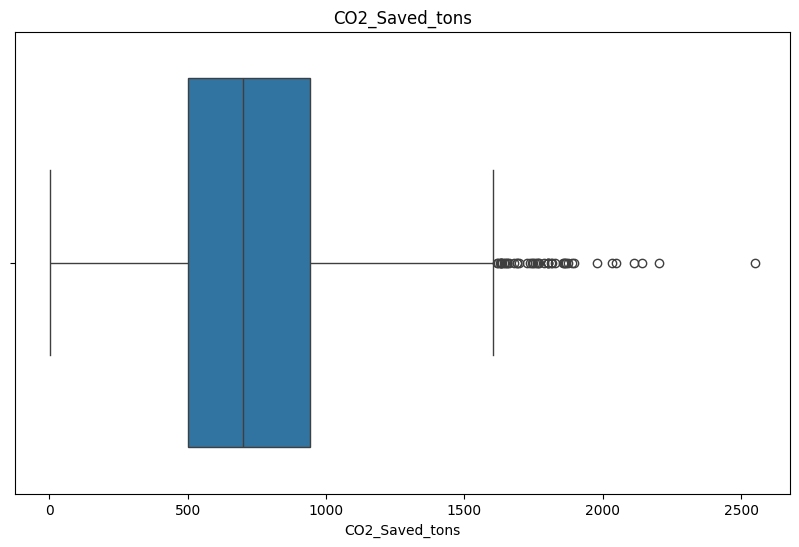

In [202]:
c=["Estimated_Deliveries","Production_Units","CO2_Saved_tons"]
for i in c:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=ev_df[i])
  plt.title(i)
  plt.show()


In [ ]:
for col in c:
  Q1=ev_df[col].quantile(0.25)
  Q3=ev_df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  ev_df[col]=np.where(ev_df[col]<lower,lower,ev_df[col])
  ev_df[col]=np.where( ev_df[col]>upper,upper,ev_df[col])

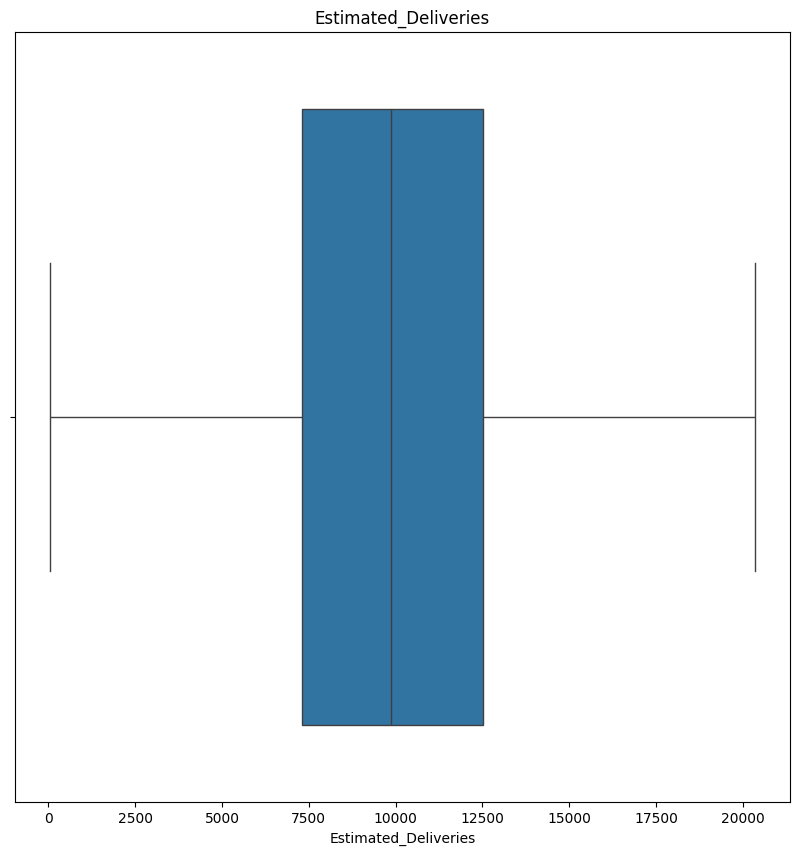

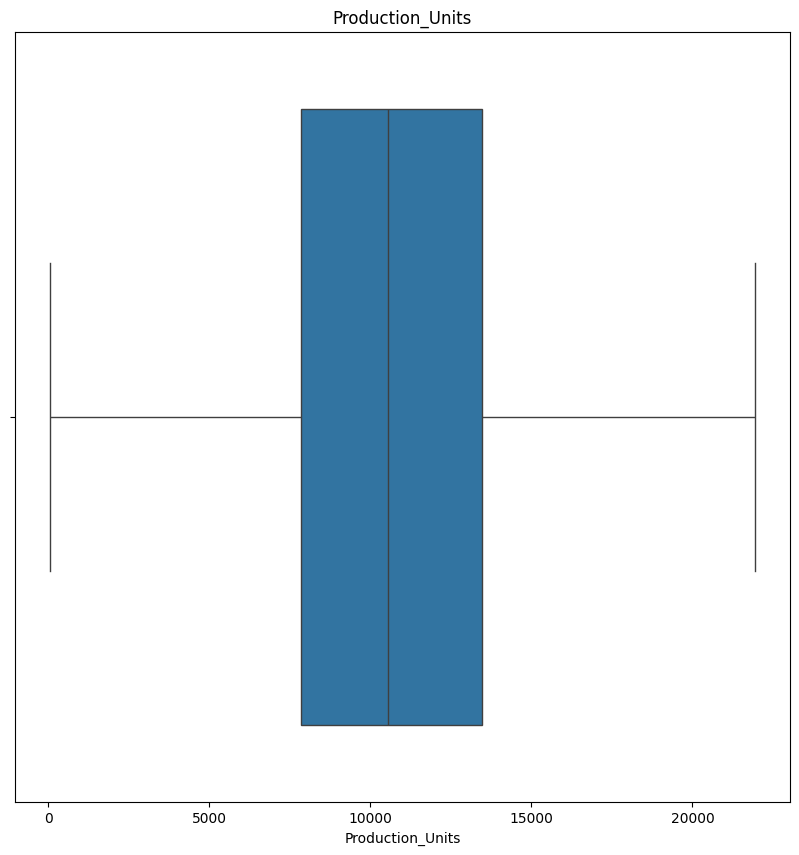

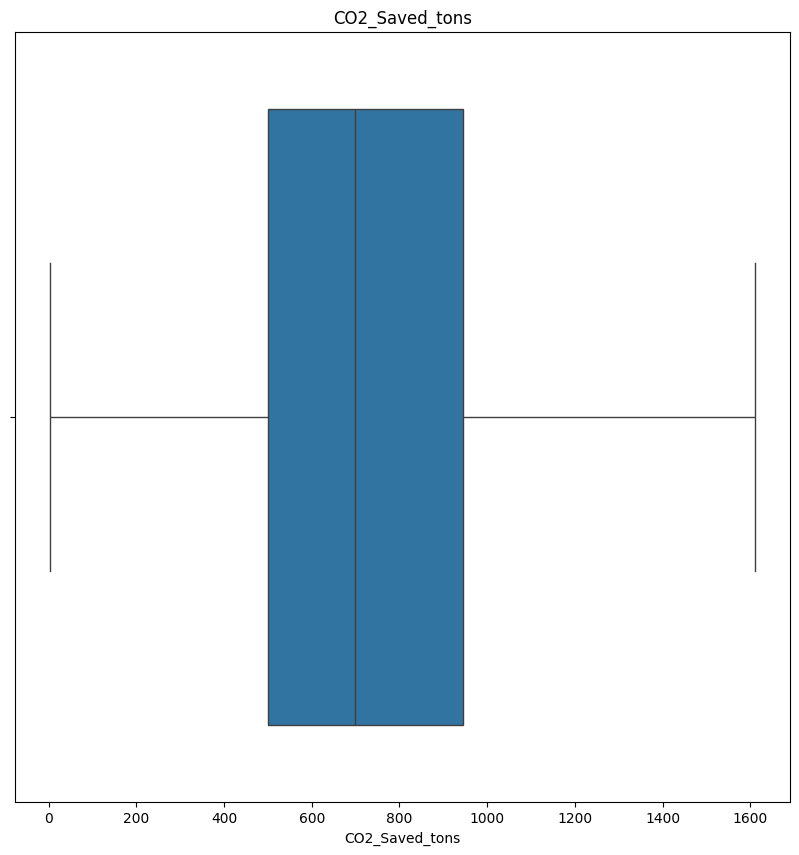

In [204]:
c=["Estimated_Deliveries","Production_Units","CO2_Saved_tons"]
for i in c:
  plt.figure(figsize=(10,10))
  sns.boxplot(x=ev_df[i])
  plt.title(i)
  plt.show()


In [205]:
ev_df= ev_df.drop(['Production_Units'], axis=1)
ev_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646.0,92874.27,120,704,1609.9825,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797.0,62205.65,75,438,249.4600,Official (Quarter),7640
2,2019,1,North America,Model X,8411.0,117887.32,82,480,605.5900,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555.0,89294.91,120,712,700.0700,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374.0,114846.78,120,661,1226.8800,Estimated (Region),8722


In [206]:
ev_df.corr(numeric_only=True)['Estimated_Deliveries'].sort_values(ascending=False)

,Estimated_Deliveries
Estimated_Deliveries,1.000000
CO2_Saved_tons,0.839164
Month,0.030730
Charging_Stations,0.001451
Year,-0.001381
Range_km,-0.006243
Battery_Capacity_kWh,-0.007531
Avg_Price_USD,-0.026679


correlation of features


Distribution of delivery


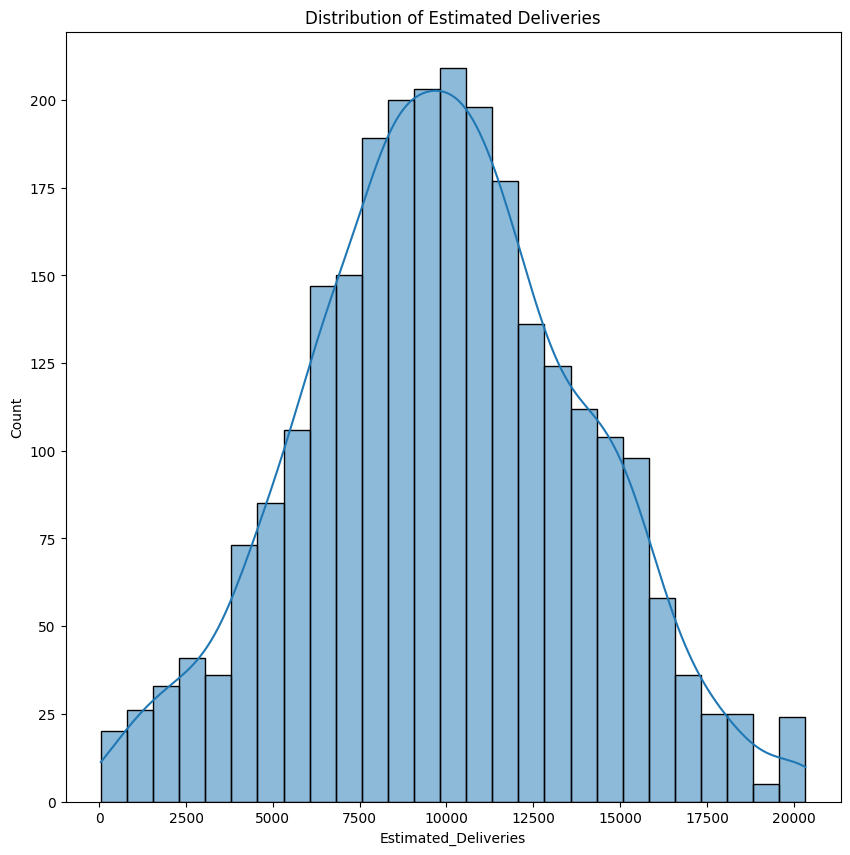

In [207]:
plt.figure(figsize=(10,10))
sns.histplot(ev_df["Estimated_Deliveries"],kde=True)

plt.title("Distribution of Estimated Deliveries")
plt.show()

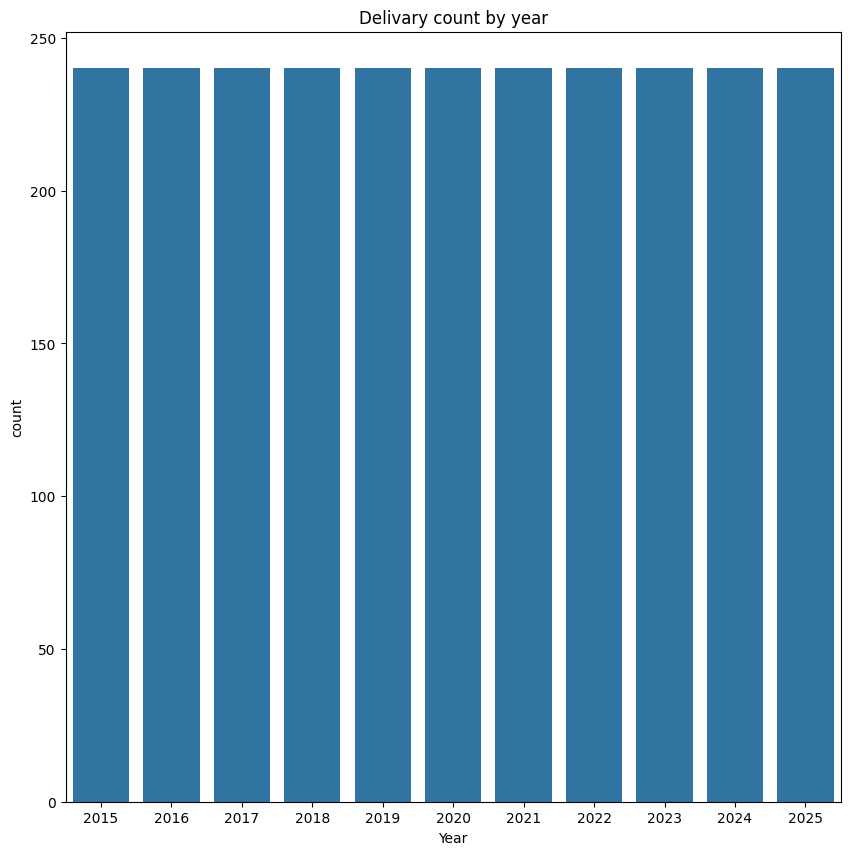

In [208]:
plt.figure(figsize=(10,10))
sns.countplot(x="Year",data=ev_df)
plt.title("Delivary count by year")
plt.show()

Delivery trend over the year

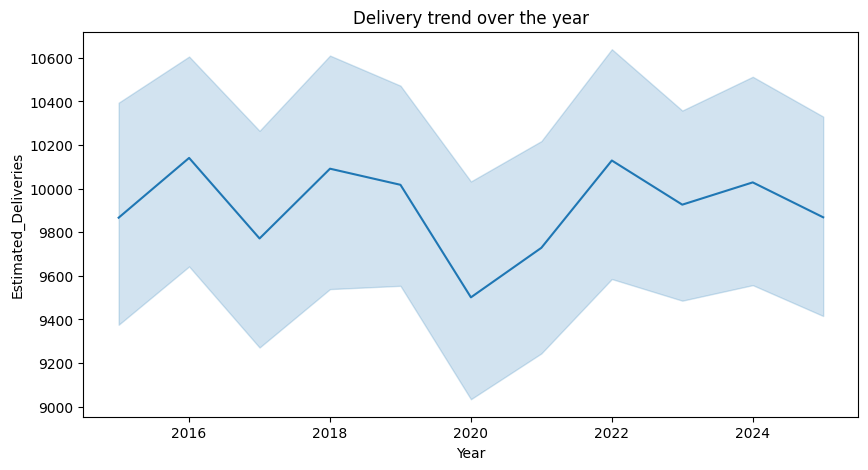

In [209]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Year",y="Estimated_Deliveries",data=ev_df)
plt.title("Delivery trend over the year")
plt.show()

check the graph linear relation


<Figure size 1000x1600 with 0 Axes>

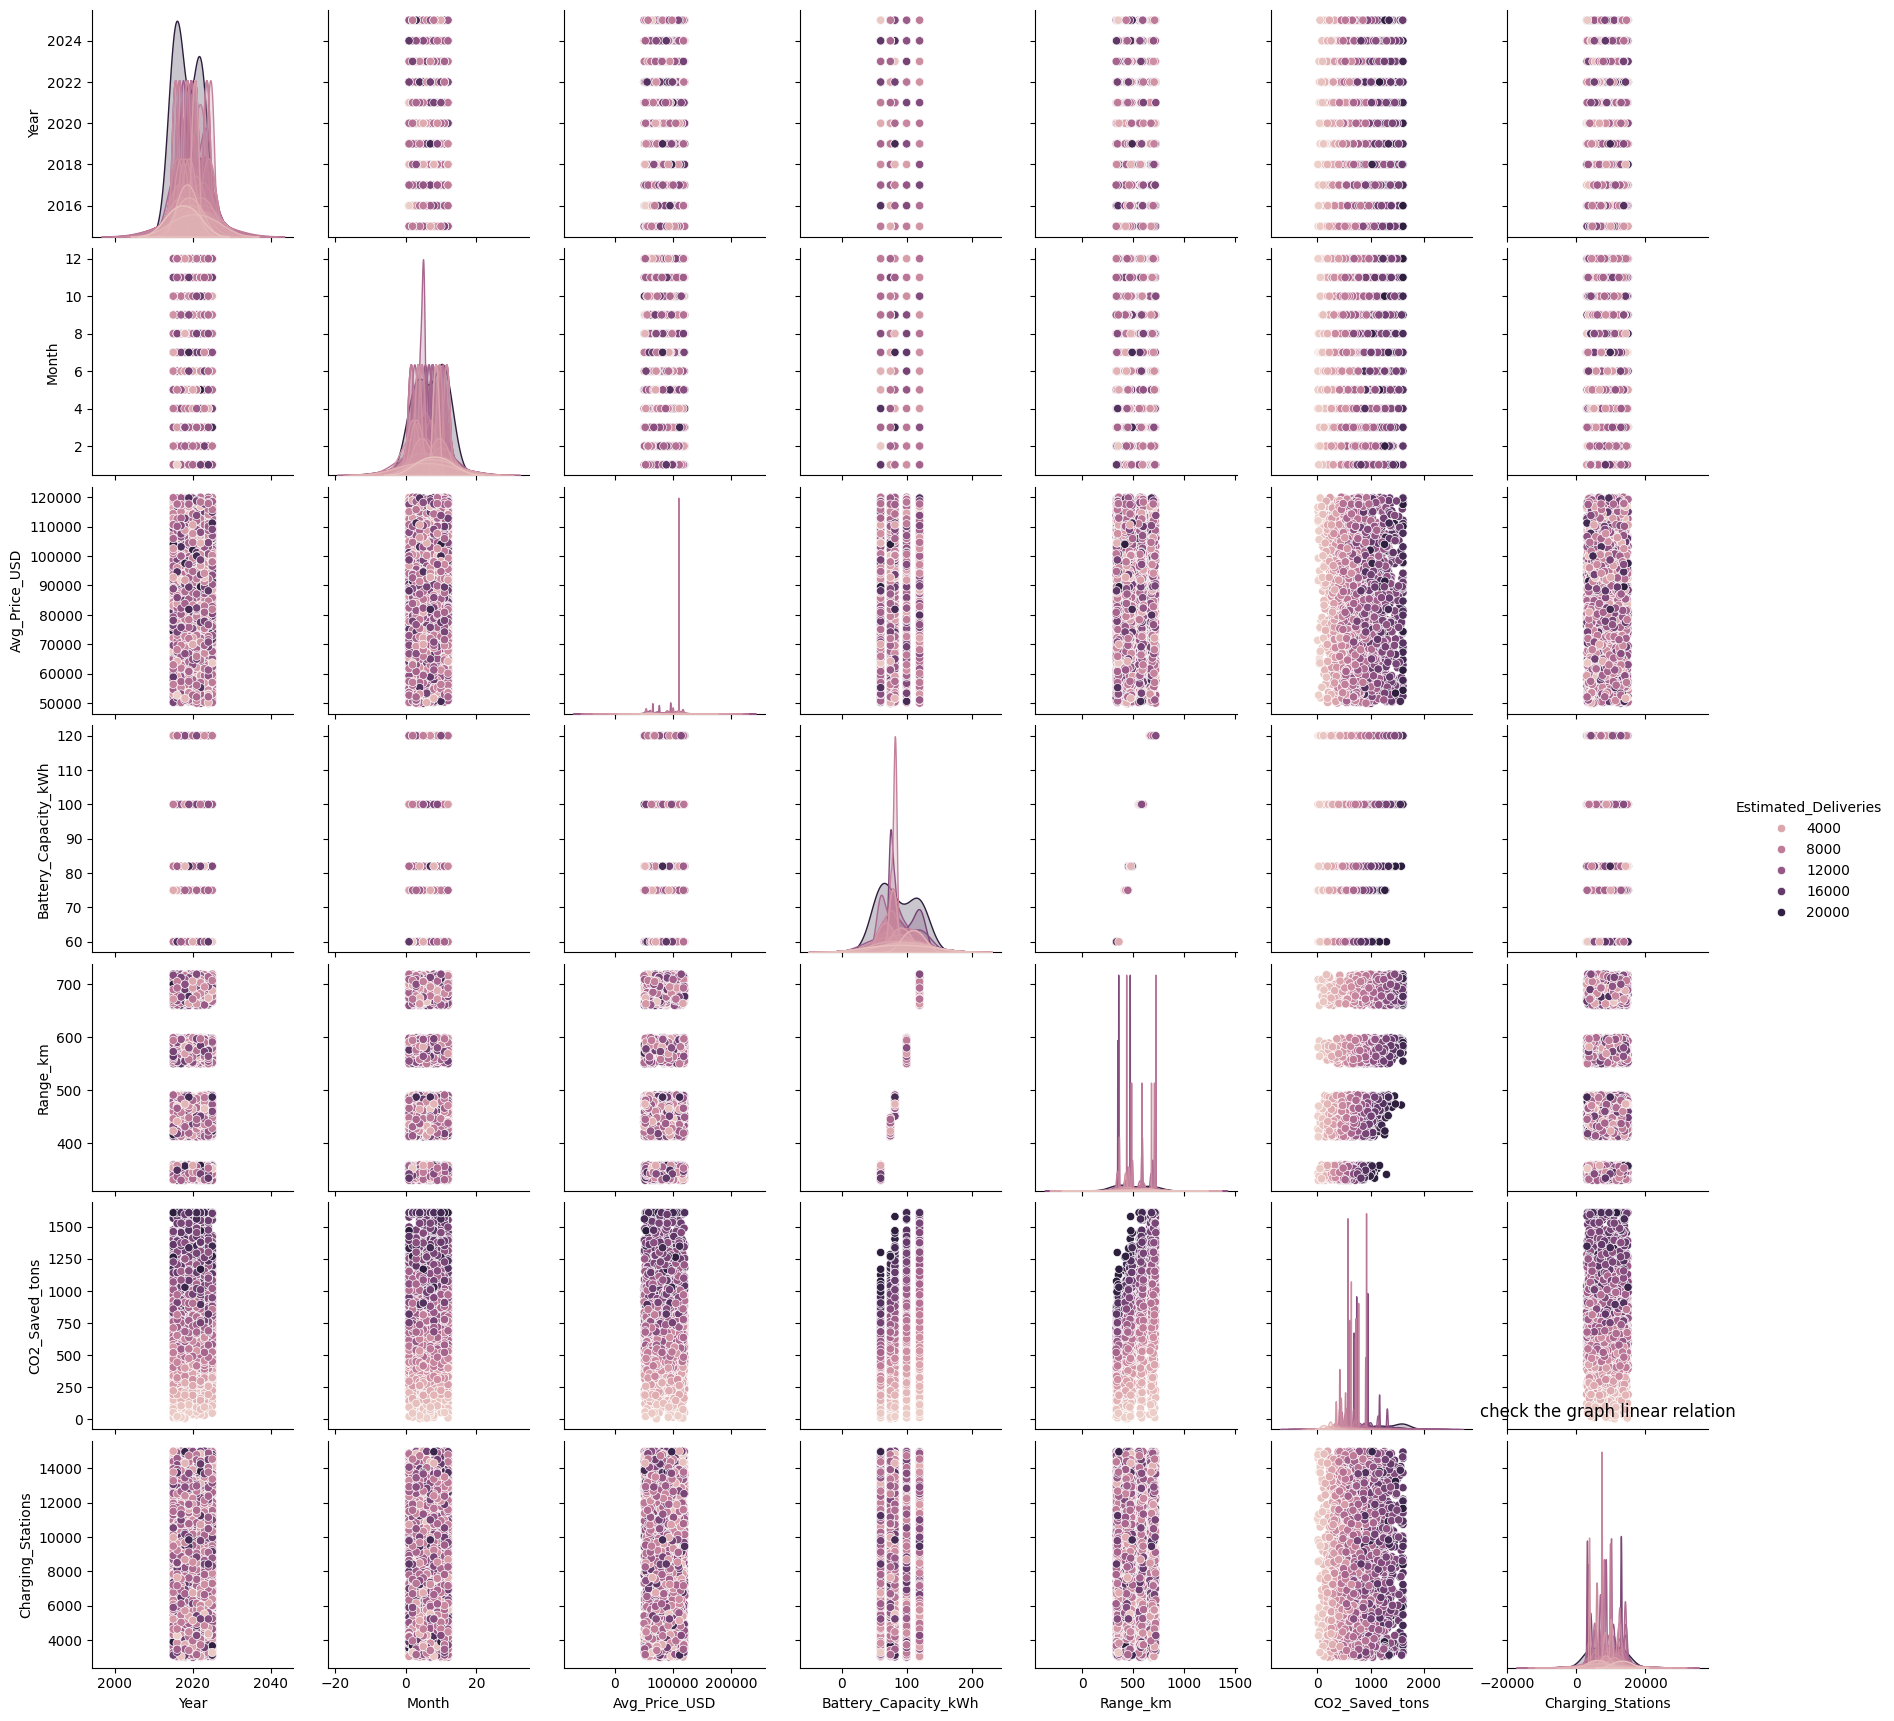

In [210]:
plt.figure(figsize=(10,16))
sns.pairplot(ev_df,hue="Estimated_Deliveries")
plt.title("check the graph linear relation")
plt.show()

price vs deliveries

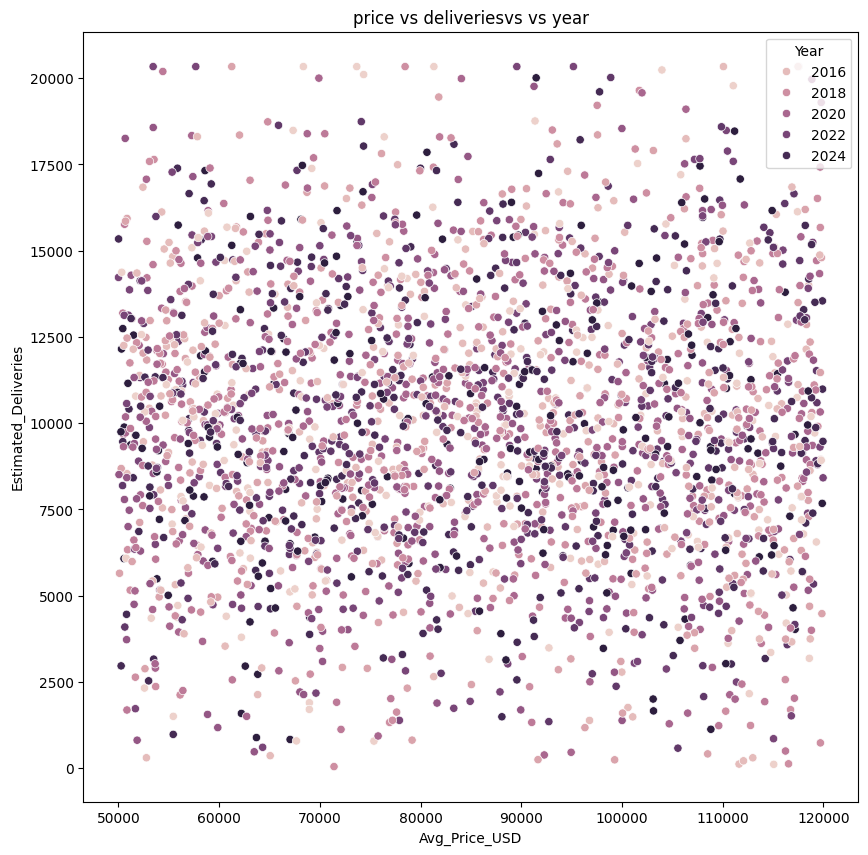

(None,)

In [211]:
plt.figure(figsize=(10,10))
sns.scatterplot(x=ev_df['Avg_Price_USD'],y=ev_df['Estimated_Deliveries'],hue=ev_df['Year'],data=ev_df)
plt.title("price vs deliveriesvs vs year")
plt.show(),

**feature** **engineering**


In [212]:

ev_df["Price_km"]=(ev_df["Avg_Price_USD"]/ev_df["Range_km"])

In [213]:
ev_df["Date"]=pd.to_datetime(ev_df[["Year", "Month"]].assign(DAY=1))

In [214]:
ev_df.head(10)


,Year,Month,Region,Model,Estimated_Deliveries,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Price_km,Date
0,2023,5,Europe,Model S,17646.0,92874.27,120,704,1609.9825,Interpolated (Month),12207,131.923679,2023-05-01
1,2015,2,Asia,Model X,3797.0,62205.65,75,438,249.4600,Official (Quarter),7640,142.022032,2015-02-01
2,2019,1,North America,Model X,8411.0,117887.32,82,480,605.5900,Interpolated (Month),14071,245.598583,2019-01-01
3,2021,2,North America,Model 3,6555.0,89294.91,120,712,700.0700,Official (Quarter),9333,125.414199,2021-02-01
4,2016,12,Middle East,Model Y,12374.0,114846.78,120,661,1226.8800,Estimated (Region),8722,173.747020,2016-12-01
5,2020,4,Asia,Model X,4656.0,86930.57,82,477,333.1400,Official (Quarter),5798,182.244382,2020-04-01
6,2015,11,Asia,Model 3,7717.0,87588.21,82,475,549.8400,Interpolated (Month),9961,184.396232,2015-11-01
7,2020,6,Europe,Cybertruck,8410.0,73815.61,100,592,746.8100,Official (Quarter),8216,124.688530,2020-06-01
8,2022,4,Europe,Model S,15145.0,69993.86,100,563,1279.0000,Interpolated (Month),13264,124.323020,2022-04-01
9,2021,3,Middle East,Model Y,7790.0,50591.60,82,485,566.7200,Interpolated (Month),3383,104.312577,2021-03-01


###**End to ML Pipe line using regression**


**Train test split**

In [215]:
X=ev_df.drop(["Estimated_Deliveries","Date"],axis=1)
y=ev_df['Estimated_Deliveries']


In [216]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**encoding and scaling**

In [226]:
cate_cols=["Region", "Model", "Source_Type"]
num_cols=X_train.select_dtypes(include=['int64','float64']).columns

t1=ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cate_cols),("num",RobustScaler(), num_cols)],remainder='passthrough')


**create a pipline**

In [227]:
c=Pipeline(steps=[('preprocess',t1),('model',Lasso())])




**Hyperparameter tuning and model training using lasso**

In [237]:
param_grid = {"model__alpha":[0.01, 0.1, 1, 10, 100,200,300]}
grid = GridSearchCV(c, param_grid,cv=7,scoring="r2")
grid.fit(X_train,y_train)

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type']),
                                                                        ('num',
                                                                         RobustScaler(),
                                                                         Index(['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Charging_Stations', 'Price_km'],
      dtype='object'))])),
                                       ('model', Lasso())]),
             param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100, 200, 300]},
             scoring='r2')

**evalution of model**

In [231]:
lr_pred=grid.predict(X_test)
print("Lasso Regression Results")
print("mae test:", mean_absolute_error(y_test, lr_pred))
print("mae train:", mean_absolute_error(y_train, grid.predict(X_train)))
print("rmse:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print(r2_score(y_test,grid.predict(X_test)))
print(r2_score(y_train,grid.predict(X_train)))

Lasso Regression Results
mae test: 636.9495786568641
mae train: 636.6246134812048
rmse: 894.4144555814873
0.9463329025193139
0.9490209441952067


In [244]:


# time series
ts = ev_df.groupby("Date")["Estimated_Deliveries"].sum()

# train-test split
train = ts[:-6]
test = ts[-6:]

# model training
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# prediction
forecast = model_fit.forecast(steps=6)

# evaluation
mae = mean_absolute_error(test, forecast)

print("Forecast MAE:", mae)

Forecast MAE: 9590.7015634131


TypeError: ARIMA.__init__() missing 1 required positional argument: 'endog'

2025-01-01    199608.007442
2025-02-01    199478.335252
2025-03-01    199461.849958
2025-04-01    199459.754174
2025-05-01    199459.487735
2025-06-01    199459.453863
2025-07-01    199459.449557
2025-08-01    199459.449009
2025-09-01    199459.448940
2025-10-01    199459.448931
2025-11-01    199459.448930
2025-12-01    199459.448930
Freq: MS, Name: predicted_mean, dtype: float64
